# Facial Recognition using Siamese Neural Networks

**Authors**: Hana Magyarová, Lenka Husárová, Martin Mislovič

In [1]:
import torch
import wandb
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc
from collections import defaultdict
from itertools import combinations


In [2]:
def set_seed(seed):
    random.seed(seed)                      
    np.random.seed(seed)                   
    torch.manual_seed(seed)                
    torch.cuda.manual_seed(seed)           
    torch.cuda.manual_seed_all(seed)       
    torch.backends.cudnn.deterministic = True  
    torch.backends.cudnn.benchmark = False 

set_seed(0)

## 1. Preprocessing the data
In this section we process the data and create specialized dataset classes for obtaining triplets.

### 1.1. Data splitting
We define the `split_dataset` which splits the data based on classes. 80% of the classe go to the train dataset, 10% goes to the validation dataset and the last 10% goes to the train dataset.

In [3]:
def split_dataset(full_dataset: ImageFolder, images_per_class: int = 1) -> tuple[Subset, Subset, Subset]:
    # group indexes according to labels
    label_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(full_dataset.samples):
        label_to_indices[label].append(idx)

    # select only people that have at least the minimal number of packages
    filtered_label_to_indices = {
        label: indices for label, indices in label_to_indices.items() if len(indices) >= images_per_class
    }

    # get only valid labels
    valid_labels = list(filtered_label_to_indices.keys())
    random.shuffle(valid_labels)

    # split labels into 80/10/10 - each identity is only in one set
    train_labels, temp_labels = train_test_split(valid_labels, test_size=0.2, random_state=0)
    val_labels, test_labels = train_test_split(temp_labels, test_size=0.5, random_state=0)

    # cerate indices for subsets
    train_indices, val_indices, test_indices = [], [], []

    for label in train_labels:
        train_indices.extend(filtered_label_to_indices[label])
    for label in val_labels:
        val_indices.extend(filtered_label_to_indices[label])
    for label in test_labels:
        test_indices.extend(filtered_label_to_indices[label])

    # fill in subsets
    train_subset = Subset(full_dataset, train_indices)
    val_subset = Subset(full_dataset, val_indices)
    test_subset = Subset(full_dataset, test_indices)
    return train_subset, val_subset, test_subset

### 1.2. Online Triplet Dataset

In [4]:
class OnlineTripletDataset(Dataset):
    def __init__(self, image_folder_dataset, min_images_per_person: int = 2):
        self.dataset = image_folder_dataset
        self.min_images_per_person = min_images_per_person

        # group indices by class
        self.class_indices = defaultdict(list)
        for index, (img, label) in enumerate(self.dataset):
            self.class_indices[label].append(index)

        self.valid_classes = [
            class_index for class_index, indices in self.class_indices.items()
            if len(indices) >= self.min_images_per_person
        ]

        self.all_classes = list(self.class_indices.keys())

        self.anchors = []
        for anchor_class in self.valid_classes:
            anchor_class_indices = self.class_indices[anchor_class]
            self.anchors.extend([
                (anchor_index, anchor_class) for anchor_index in anchor_class_indices
            ])

        print(f"Initialized OnlineTripletDataset with {len(self.valid_classes)} valid classes.")

    def __len__(self):
        return len(self.anchors)
        
    def __getitem__(self, idx):
        anchor_index, anchor_class = self.anchors[idx]

        # Sample a positive example from the same class (but not the anchor)
        positive_candidates = self.class_indices[anchor_class].copy()
        positive_candidates.remove(anchor_index)
        positive_index = random.choice(positive_candidates)

        negative_class = random.choice([cls for cls in self.all_classes if cls != anchor_class])
        negative_index = random.choice(self.class_indices[negative_class])

        anchor_img, _ = self.dataset[anchor_index]
        positive_img, _ = self.dataset[positive_index]
        negative_img, _ = self.dataset[negative_index]

        return anchor_img, positive_img, negative_img

### 1.3. Pair dataset

In [5]:
def create_pairs(dataset):
    label_to_indices = defaultdict(list)
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_to_indices[label].append(idx)

    same_pairs = []
    diff_pairs = []

    # same identity pairs
    for label, indices in label_to_indices.items():
        for i, j in combinations(indices, 2):
            same_pairs.append((i, j, 1))  # 1 - same

    # different identity pairs
    labels = list(label_to_indices.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            indices_i = label_to_indices[labels[i]]
            indices_j = label_to_indices[labels[j]]
            for idx_i in indices_i:
                for idx_j in indices_j:
                    diff_pairs.append((idx_i, idx_j, 0))  # 0 - different
                    
    print(f"Number of same pairs: {len(same_pairs)}")
    print(f"Number of different pairs: {len(diff_pairs)}")
    return same_pairs + diff_pairs

### 1.4. Initializing the datasets

In [6]:
# transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
                mean=[0.4332, 0.3757, 0.3340],
                std=[0.2982, 0.2732, 0.2665]),
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Augmentation: random horizontal flip
    transforms.RandomRotation(10),      # Augmentation: random rotation by 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),  # Augmentation: color jitter
    transforms.ToTensor(),
    transforms.Normalize(
                mean=[0.4332, 0.3757, 0.3340],
                std=[0.2982, 0.2732, 0.2665]),
])

# dataset laod
full_dataset = ImageFolder("data", transform=transform)

train_subset, val_subset, test_subset = split_dataset(full_dataset)

# create datasets
train_dataset = OnlineTripletDataset(train_subset)
val_dataset = OnlineTripletDataset(val_subset)
test_pairs = create_pairs(test_subset)

train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=60, shuffle=False)

Initialized OnlineTripletDataset with 1339 valid classes.
Initialized OnlineTripletDataset with 183 valid classes.
Number of same pairs: 3290
Number of different pairs: 613315


### 1.5. Triplet check

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4527162..2.499062].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4527162..2.469632].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4527162..2.1900454].


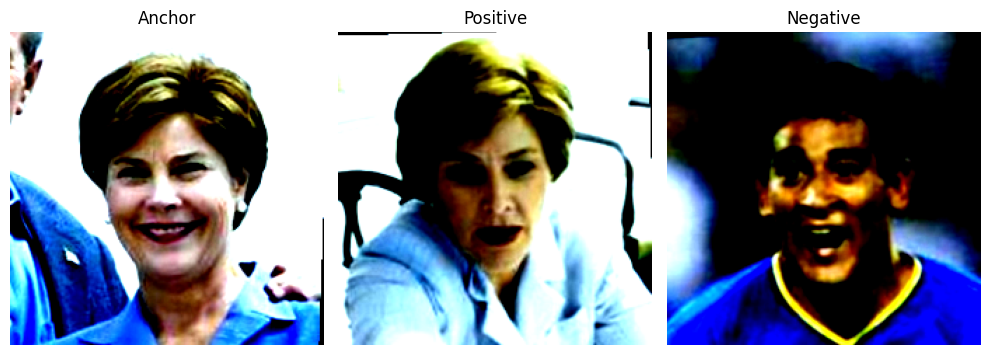

In [7]:
# random triplet check
anchor_batch, positive_batch, negative_batch = next(iter(train_loader))

# select first triplet from batch
anchor = anchor_batch[0].permute(1, 2, 0)
positive = positive_batch[0].permute(1, 2, 0)
negative = negative_batch[0].permute(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
titles = ["Anchor", "Positive", "Negative"]
for ax, img, title in zip(axes, [anchor, positive, negative], titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Model definitions

### 2.1. ResNet18

In [8]:
class ResidualBlock(nn.Module):
    expanstion = 1

    def __init__(self, input_channels: int, output_channels: int, stride: int = 1):
        super().__init__()
        self.normal_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(output_channels)
        )

        self.skip_conntect = nn.Sequential()

        if stride != 1 or input_channels != self.expanstion * output_channels:
            self.skip_conntect = nn.Sequential(
                nn.Conv2d(input_channels, self.expanstion * output_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expanstion * output_channels)
            )
    

    def forward(self, x):
        out = self.normal_path(x)
        out += self.skip_conntect(x)
        out = F.relu(out)
        return out

In [9]:
class NeuralNet(nn.Module):
    def __init__(self, embedding_size: int):
        super(NeuralNet, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 64, stride=1),

            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=2),

            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=2),

            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512, stride=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fully_connected = nn.Sequential(
            nn.Linear(512, embedding_size)
        )

    
    def forward(self, x: torch.Tensor):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        x = F.normalize(x, p=2, dim=1)
        return x
    

### 2.2. Simplified ResNet18

In [10]:
class SimplifiedResidualBlock(nn.Module):
    expansion = 1

    def __init__(self, input_channels: int, output_channels: int, stride: int = 1):
        super().__init__()
        self.normal_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(output_channels)
        )

        # skip connection, but we use it only when its necessary (stride or channels mismatch)
        self.skip_connection = nn.Identity()

        if stride != 1 or input_channels != self.expansion * output_channels:
            self.skip_connection = nn.Sequential(
                nn.Conv2d(input_channels, self.expansion * output_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * output_channels)
            )

    def forward(self, x):
        out = self.normal_path(x)
        out += self.skip_connection(x)
        out = F.relu(out)
        return out


class SimplifiedNeuralNet(nn.Module):
    def __init__(self, embedding_size: int):
        super(SimplifiedNeuralNet, self).__init__()

        # feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # reduced residual blocks
            SimplifiedResidualBlock(64, 64, stride=1),
            SimplifiedResidualBlock(64, 128, stride=2),
            SimplifiedResidualBlock(128, 128, stride=1),
            SimplifiedResidualBlock(128, 256, stride=1),
            SimplifiedResidualBlock(256, 256, stride=1),


            # pooling
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fully_connected = nn.Sequential(
            nn.Linear(256, embedding_size),
        )

    def forward(self, x: torch.Tensor):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        x = F.normalize(x, p=2, dim=1)  # normalize the embedding
        return x


## 3. Select device

In [11]:
def select_device():
    if torch.cuda.is_available():
        print("Currently using: Nvidia CUDA")
        device = torch.device("cuda")
    elif torch.mps.is_available():
        print("Currently using: Apple Metal Performance Shaders")
        device = torch.device("mps")
    else:
        print("Currently using: CPU")
        device = torch.device("cpu")
    return device

device = select_device()

Currently using: Nvidia CUDA


## 4. Training and Testing

In [12]:
def train(model: nn.Module, loss_function: nn.Module, optimizer, scheduler, epochs, train_loader, val_loader, use_wandb: bool = True):
    for epoch in range(epochs):
        model.train()
        print(f"--- Epoch {epoch + 1} ---")
        losses = []
        val_losses = []
        with tqdm(train_loader) as progress:
            for anchor_img, positive_img, negative_img in progress:
                optimizer.zero_grad()

                anchor_img = anchor_img.to(device)
                positive_img = positive_img.to(device)
                negative_img = negative_img.to(device)

                anchor_embed = model.forward(anchor_img)
                positive_embed = model.forward(positive_img)
                negative_embed = model.forward(negative_img)

                loss = loss_function(anchor_embed, positive_embed, negative_embed)
                losses.append(loss.item())
                progress.set_postfix(mean_loss = f"{sum(losses)/len(losses)}")
                loss.backward()
                optimizer.step()
        
        model.eval()
        with tqdm(val_loader) as progress:
            distances = []
            labels = []
            for anchor_img, positive_img, negative_img in progress:
                with torch.no_grad():
                    anchor_img = anchor_img.to(device)
                    positive_img = positive_img.to(device)
                    negative_img = negative_img.to(device)

                    anchor_embed = model.forward(anchor_img)
                    positive_embed = model.forward(positive_img)
                    negative_embed = model.forward(negative_img)

                    loss = loss_function(anchor_embed, positive_embed, negative_embed)
                    val_losses.append(loss.item())
                    progress.set_postfix(mean_loss = f"{sum(val_losses)/len(val_losses)}")

                    batch_size = anchor_embed.shape[0]

                    distances.extend(torch.sum((anchor_embed - positive_embed) ** 2, dim=1).cpu().numpy())
                    labels.extend([1] * batch_size)
                    distances.extend(torch.sum((anchor_embed - negative_embed) ** 2, dim=1).cpu().numpy())
                    labels.extend([0] * batch_size)
                
            distances = np.array(distances)
            labels = np.array(labels)

            fars = []
            frrs = []
            tars = []
            thresholds = np.linspace(distances.min(), distances.max(), 1000)

            for threshold in thresholds:
                predictions = (distances < threshold).astype(int)
                TP = np.sum((predictions == 1) & (labels == 1))
                TN = np.sum((predictions == 0) & (labels == 0))
                FP = np.sum((predictions == 1) & (labels == 0))
                FN = np.sum((predictions == 0) & (labels == 1))
                FAR = FP / (FP + TN + 1e-8)
                FRR = FN / (TP + FN + 1e-8)
                TAR = 1 - FRR
                fars.append(FAR)
                frrs.append(FRR)
                tars.append(TAR)
            fars = np.array(fars)
            frrs = np.array(frrs)
            tars = np.array(tars)
            min_index = np.argmin(np.abs(fars - frrs))
            eer = (fars[min_index] + frrs[min_index]) / 2
            eer_threshold = thresholds[min_index]
            
            print(f"TAR@FAR=10%: {tars[np.argmin(np.abs(fars - 0.1))]}")
            print(f"TAR@FAR=5%: {tars[np.argmin(np.abs(fars - 0.05))]}")
            print(f"TAR@FAR=1%: {tars[np.argmin(np.abs(fars - 0.01))]}")
            print(f"AUC: {auc(fars, tars)}")
            print(f"EER: {eer}")
            print(f"EER Threshold {eer_threshold}")


            if use_wandb:
                wandb.log({
                    "train_loss": sum(losses)/len(losses),
                    "validation_tar_at_far_10": tars[np.argmin(np.abs(fars - 0.1))],
                    "validation_tar_at_far_5": tars[np.argmin(np.abs(fars - 0.05))],
                    "validation_tar_at_far_1": tars[np.argmin(np.abs(fars - 0.01))],
                    "validation_auc": auc(fars, tars),
                    "validation_eer": eer,
                    "validation_loss": sum(val_losses)/len(val_losses),
                    }
                )
            scheduler.step()


### 4.1. Testing the model

In [13]:
def test(model, dataset, pairs, use_wandb=True):
    model.eval()
    device = next(model.parameters()).device  # zbieham to na GPU a bol problem s tensors (vieme to upravit ak tak)
    embeddings = {}

    with torch.no_grad():
        for idx in set([i for i, _, _ in pairs] + [j for _, j, _ in pairs]):
            img, _ = dataset[idx]
            img = img.unsqueeze(0).to(device)  # batch dim 
            embedding = model(img).squeeze(0).cpu()  
            embeddings[idx] = embedding

    distances = []
    labels = []

    # vypocitaj vzdialenost pre embeddings
    for idx1, idx2, label in pairs:
        emb1 = embeddings[idx1]
        emb2 = embeddings[idx2]
        dist = torch.norm(emb1 - emb2).item()  # vzdialenost
        distances.append(dist)
        labels.append(label)

    distances = np.array(distances)
    labels = np.array(labels)

    fars = []
    frrs = []
    tars = []
    thresholds = np.linspace(distances.min(), distances.max(), 1000)

    for threshold in thresholds:
        predictions = (distances < threshold).astype(int)
        TP = np.sum((predictions == 1) & (labels == 1))
        TN = np.sum((predictions == 0) & (labels == 0))
        FP = np.sum((predictions == 1) & (labels == 0))
        FN = np.sum((predictions == 0) & (labels == 1))
        FAR = FP / (FP + TN + 1e-8)
        FRR = FN / (TP + FN + 1e-8)
        TAR = 1 - FRR
        fars.append(FAR)
        frrs.append(FRR)
        tars.append(TAR)
    fars = np.array(fars)
    frrs = np.array(frrs)
    tars = np.array(tars)
    min_index = np.argmin(np.abs(fars - frrs))
    eer = (fars[min_index] + frrs[min_index]) / 2
    eer_threshold = thresholds[min_index]
    
    print(f"TAR@FAR=10%: {tars[np.argmin(np.abs(fars - 0.1))]}")
    print(f"TAR@FAR=5%: {tars[np.argmin(np.abs(fars - 0.05))]}")
    print(f"TAR@FAR=1%: {tars[np.argmin(np.abs(fars - 0.01))]}")
    print(f"AUC: {auc(fars, tars)}")
    print(f"EER: {eer}")
    print(f"EER Threshold {eer_threshold}")

    fig = plt.figure(figsize=(8, 6))
    plt.plot(fars, tars, label='ROC Curve', color='blue')
    plt.xlabel('False Accept Rate (FAR)')
    plt.ylabel('True Accept Rate (TAR)')
    plt.title('ROC Curve for Face Verification - Test')
    plt.grid(True)
    plt.legend()
    plt.show()

    if use_wandb:
        wandb.log({
            "test_tar_at_far_10": tars[np.argmin(np.abs(fars - 0.1))],
            "test_tar_at_far_5": tars[np.argmin(np.abs(fars - 0.05))],
            "test_tar_at_far_1": tars[np.argmin(np.abs(fars - 0.01))],
            "test_auc": auc(fars, tars),
            "test_eer": eer,
            "test_roc": wandb.Image(fig)
            }
        )

## 5. Loss functions

In [14]:
class ShadowLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        anchor_norm = anchor.norm(dim=1, keepdim=True)

        pa_p = (anchor * positive).sum(dim=1, keepdim=True) / anchor_norm
        pa_n = (anchor * negative).sum(dim=1, keepdim=True) / anchor_norm

        p = (anchor_norm - pa_p).abs()
        n = (anchor_norm - pa_n).abs()

        loss = torch.clamp(p - n + self.margin, min=0.0)
        return loss.mean()

## 6. Experimentation

In [15]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "validation_eer",
        "goal": "minimize"
    },
    "parameters": {
        "batch_size": {
            "min": 16,
            "max": 64
        },
        "margin":{
            "min": 0.0,
            "max": 1.0,
        },
        "lr": {
            "min": 0.00001,
            "max": 0.001
        },
        "weight_decay": {
            "min": 0.01,
            "max": 1.0
        },
        "embedding_size": {
            "min": 32,
            "max": 256
        }
    }
}

### 6.1. Shadow loss vs. Triplet loss

In [16]:
def sweep_shadow():
    wandb.init()
    config = wandb.config
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
    model: nn.Module = NeuralNet(config.embedding_size).to(device)
    loss = ShadowLoss(margin=config.margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(model, loss, optimizer, scheduler, 10, train_loader, val_loader)
    print("--- Test ---")
    test(model, test_subset, test_pairs)

def sweep_triplet():
    wandb.init()
    config = wandb.config
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
    model: nn.Module = NeuralNet(config.embedding_size).to(device)
    loss = nn.TripletMarginLoss(margin=config.margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(model, loss, optimizer, scheduler, 10, train_loader, val_loader)
    print("--- Test ---")
    test(model, test_subset, test_pairs)

Create sweep with ID: w9edadvo
Sweep URL: https://wandb.ai/xmagyarova-stu/nsiete-project-3/sweeps/w9edadvo


wandb: Agent Starting Run: 0eccxrm3 with config:
wandb: 	batch_size: 59
wandb: 	embedding_size: 255
wandb: 	lr: 0.0007195979067589388
wandb: 	margin: 0.5394671970643762
wandb: 	weight_decay: 0.05260402963394551
wandb: Currently logged in as: xmagyarova (xmagyarova-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--- Epoch 1 ---


100%|██████████| 15/15 [00:04<00:00,  3.09it/s, mean_loss=0.3006159424781799] 


TAR@FAR=10%: 0.392090395487095
TAR@FAR=5%: 0.25536723164683206
TAR@FAR=1%: 0.06666666667721277
AUC: 0.7712604934663586
EER: 0.31073446327332505
EER Threshold 1.029072880744934
--- Epoch 2 ---


...

TAR@FAR=10%: 0.47683615819800185
TAR@FAR=5%: 0.3073446327761882
TAR@FAR=1%: 0.1129943502925086
AUC: 0.819753582935083
EER: 0.2536723163813145
EER Threshold 0.7176743149757385
--- Epoch 9 ---


100%|██████████| 15/15 [00:04<00:00,  3.06it/s, mean_loss=0.28577729761600495]


TAR@FAR=10%: 0.45423728814176
TAR@FAR=5%: 0.28248587571432215
TAR@FAR=1%: 0.09265536724189094
AUC: 0.8124281017516806
EER: 0.27118644067490183
EER Threshold 0.5689324736595154
--- Epoch 10 ---


100%|██████████| 15/15 [00:04<00:00,  3.05it/s, mean_loss=0.24182827671368917]


TAR@FAR=10%: 0.5096045197795525
TAR@FAR=5%: 0.3073446327761882
TAR@FAR=1%: 0.06666666667721277
AUC: 0.8307836190036517
EER: 0.2559322033869386
EER Threshold 0.7161501049995422
--- Test ---
TAR@FAR=10%: 0.3863221884517133
TAR@FAR=5%: 0.25835866261623597
TAR@FAR=1%: 0.08693009118818562
AUC: 0.7765391877180607
EER: 0.29667339360840367
EER Threshold 0.8844235727006012


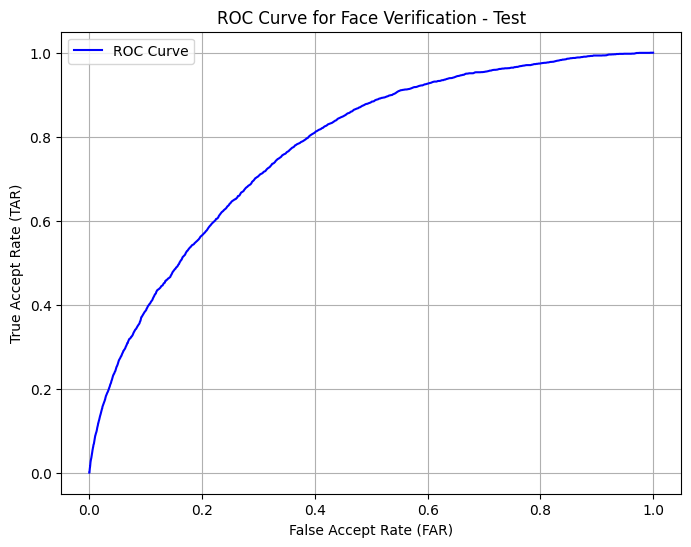

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▃▂▂▁▁▁
validation_auc,▂▃▃▁▃▃▄▇▆█
validation_eer,█▄▄█▆▅▄▁▃▁
validation_loss,▇▅▆█▇▇▄▃▅▁
validation_tar_at_far_1,▂▇▅▂▁▃▅█▅▂
validation_tar_at_far_10,▃▁▄▁▂▂▅▇▆█


wandb: Agent Starting Run: jc9z2y8i with config:
wandb: 	batch_size: 40
wandb: 	embedding_size: 170
wandb: 	lr: 0.00015190694252296914
wandb: 	margin: 0.543865743041052
wandb: 	weight_decay: 0.7852793732389662


--- Epoch 1 ---


100%|██████████| 23/23 [00:04<00:00,  4.61it/s, mean_loss=0.28115405304276425]


TAR@FAR=10%: 0.4327683615883303
TAR@FAR=5%: 0.24632768362433533
TAR@FAR=1%: 0.10282485876719971
AUC: 0.7970474640042544
EER: 0.26610169491224744
EER Threshold 1.240573763847351
--- Epoch 2 ---


...

TAR@FAR=10%: 0.7288135593250982
TAR@FAR=5%: 0.5706214689314054
TAR@FAR=1%: 0.21016949153434838
AUC: 0.9050566567625147
EER: 0.17570621468728015
EER Threshold 1.2117416858673096
--- Epoch 9 ---


100%|██████████| 23/23 [00:05<00:00,  4.57it/s, mean_loss=0.155302412322034]  


TAR@FAR=10%: 0.6824858757098025
TAR@FAR=5%: 0.5096045197795525
TAR@FAR=1%: 0.21242937853997257
AUC: 0.8980790960361889
EER: 0.17175141242743783
EER Threshold 1.1630444526672363
--- Epoch 10 ---


100%|██████████| 23/23 [00:04<00:00,  4.66it/s, mean_loss=0.14360064138536868]


TAR@FAR=10%: 0.7163841807941651
TAR@FAR=5%: 0.5966101694960835
TAR@FAR=1%: 0.2158192090484088
AUC: 0.9130945769002243
EER: 0.17118644067603178
EER Threshold 1.2322065830230713
--- Test ---
TAR@FAR=10%: 0.6297872340436784
TAR@FAR=5%: 0.4288753799409456
TAR@FAR=1%: 0.16717325228216662
AUC: 0.8840634506382051
EER: 0.19386759289334382
EER Threshold 1.1474634150529768


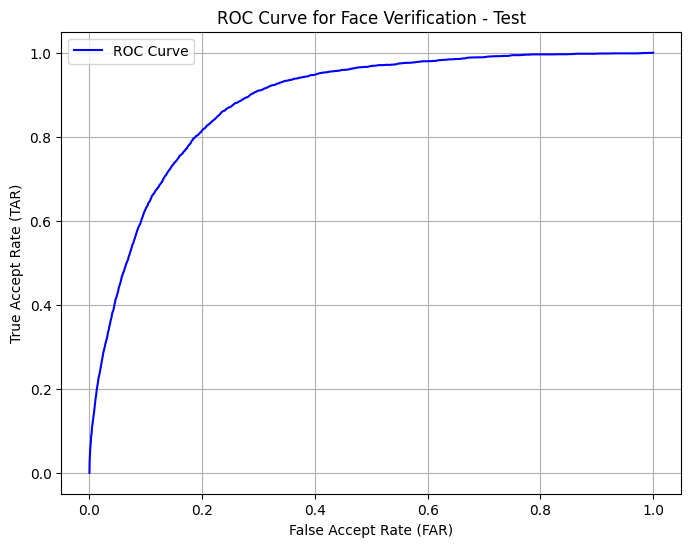

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▄▃▃▂▂▁▁▁
validation_auc,▁▄▅▆▆▆▇█▇█
validation_eer,█▆▄▂▂▂▁▁▁▁
validation_loss,█▅▃▂▂▂▁▁▂▁
validation_tar_at_far_1,▁▂▆▃▇▁▅███
validation_tar_at_far_10,▁▂▅▆▆▇▇█▇█


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hocmvk3s with config:
wandb: 	batch_size: 58
wandb: 	embedding_size: 124
wandb: 	lr: 0.0008053248712495344
wandb: 	margin: 0.10797025170296592
wandb: 	weight_decay: 0.4707712240478096


--- Epoch 1 ---


100%|██████████| 16/16 [00:04<00:00,  3.28it/s, mean_loss=0.054882952477782965]


TAR@FAR=10%: 0.38531073447022246
TAR@FAR=5%: 0.22824858757934186
TAR@FAR=1%: 0.07344632769408532
AUC: 0.7879096045132548
EER: 0.2864406779628651
EER Threshold 0.2793033719062805
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5570621468976603
TAR@FAR=5%: 0.35254237288867185
TAR@FAR=1%: 0.11525423729813278
AUC: 0.8450655941701073
EER: 0.2344632768335089
EER Threshold 0.38658857345581055
--- Epoch 9 ---


100%|██████████| 16/16 [00:04<00:00,  3.37it/s, mean_loss=0.042106013861484826]


TAR@FAR=10%: 0.5141242937908008
TAR@FAR=5%: 0.3514124293858597
TAR@FAR=1%: 0.14689265537687124
AUC: 0.8472444061334148
EER: 0.22881355931944844
EER Threshold 0.4492655396461487
--- Epoch 10 ---


100%|██████████| 16/16 [00:04<00:00,  3.33it/s, mean_loss=0.04008060728665441] 


TAR@FAR=10%: 0.5457627118695394
TAR@FAR=5%: 0.39322033898990716
TAR@FAR=1%: 0.18192090396404614
AUC: 0.8580912253741284
EER: 0.22372881355679403
EER Threshold 0.5689481496810913
--- Test ---
TAR@FAR=10%: 0.46382978723567225
TAR@FAR=5%: 0.3100303951388753
TAR@FAR=1%: 0.11033434650726337
AUC: 0.8198681979571913
EER: 0.2599017901292653
EER Threshold 0.7664581523747654


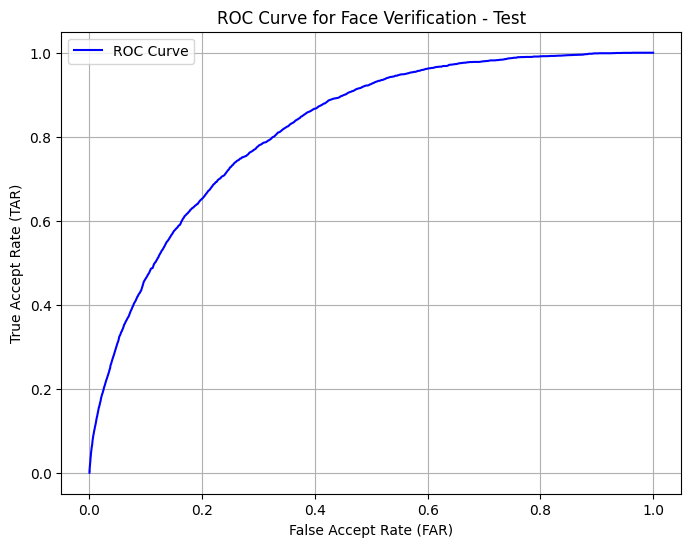

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▃▂▂▁▁▁
validation_auc,▃▄▆▅▁▄▅▇▇█
validation_eer,█▆▃▅█▇▅▂▂▁
validation_loss,▆▄▃▄█▆▃▁▃▂
validation_tar_at_far_1,▁▁▁▅▂▄▄▄▆█
validation_tar_at_far_10,▁▂█▅▁▃▆█▆█


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: h4kshby7 with config:
wandb: 	batch_size: 43
wandb: 	embedding_size: 124
wandb: 	lr: 0.00022675574651471791
wandb: 	margin: 0.5652452660956384
wandb: 	weight_decay: 0.7458008224364949


--- Epoch 1 ---


100%|██████████| 21/21 [00:04<00:00,  4.23it/s, mean_loss=0.26850260616767974]


TAR@FAR=10%: 0.4587570621530084
TAR@FAR=5%: 0.30960451978181236
TAR@FAR=1%: 0.12655367232625359
AUC: 0.8106763701292616
EER: 0.26610169491224744
EER Threshold 1.2135053873062134
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5514124293835998
TAR@FAR=5%: 0.42259887006302144
TAR@FAR=1%: 0.1378531073543745
AUC: 0.8657288773896601
EER: 0.22485875705960612
EER Threshold 0.8714614510536194
--- Epoch 9 ---


100%|██████████| 21/21 [00:04<00:00,  4.21it/s, mean_loss=0.24674045223565327]


TAR@FAR=10%: 0.5683615819257812
TAR@FAR=5%: 0.37966101695616206
TAR@FAR=1%: 0.13898305085718665
AUC: 0.8616534201456654
EER: 0.21920903954554566
EER Threshold 0.6883166432380676
--- Epoch 10 ---


100%|██████████| 21/21 [00:05<00:00,  4.12it/s, mean_loss=0.17817818089610055]


TAR@FAR=10%: 0.6124293785354528
TAR@FAR=5%: 0.4858757062204986
TAR@FAR=1%: 0.19548022599779125
AUC: 0.882751444340024
EER: 0.19943502824633408
EER Threshold 1.3212894201278687
--- Test ---
TAR@FAR=10%: 0.5571428571442032
TAR@FAR=5%: 0.36778115501711917
TAR@FAR=1%: 0.13313069909078068
AUC: 0.8558943133967517
EER: 0.20817153365552643
EER Threshold 1.1783632202310723


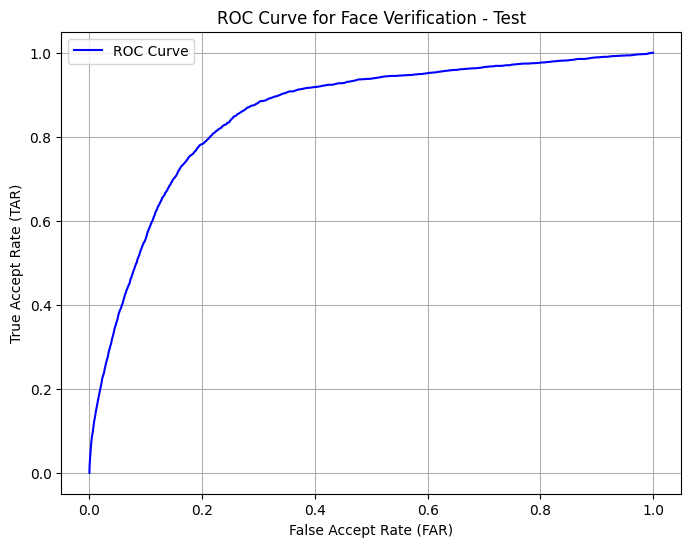

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▃▃▂▁▁▁
validation_auc,▁▄▄▇▆▇█▆▆█
validation_eer,█▄▅▂▄▂▃▄▃▁
validation_loss,█▅▅▂▃▃▃▅▆▁
validation_tar_at_far_1,▃▄▁▅▃▄█▄▄█
validation_tar_at_far_10,▁▄▄▅▆▅█▄▅▇


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: uafy7lqw with config:
wandb: 	batch_size: 46
wandb: 	embedding_size: 179
wandb: 	lr: 0.00011785358473456366
wandb: 	margin: 0.48519856553612783
wandb: 	weight_decay: 0.7258338277928656


--- Epoch 1 ---


100%|██████████| 20/20 [00:04<00:00,  4.03it/s, mean_loss=0.24250995591282845]


TAR@FAR=10%: 0.40338983051521593
TAR@FAR=5%: 0.25762711865245624
TAR@FAR=1%: 0.08474576272220624
AUC: 0.7939934246158975
EER: 0.2790960451945865
EER Threshold 1.2413852214813232
--- Epoch 2 ---


...

TAR@FAR=10%: 0.6135593220382649
TAR@FAR=5%: 0.38757062147584664
TAR@FAR=1%: 0.1514124293881196
AUC: 0.8833515273302113
EER: 0.19152542372664944
EER Threshold 1.1997723579406738
--- Epoch 9 ---


100%|██████████| 20/20 [00:04<00:00,  4.02it/s, mean_loss=0.13342562802135943]


TAR@FAR=10%: 0.6677966101732453
TAR@FAR=5%: 0.48248587571206236
TAR@FAR=1%: 0.22033898305965716
AUC: 0.8986095949349607
EER: 0.17344632768165597
EER Threshold 1.2595361471176147
--- Epoch 10 ---


100%|██████████| 20/20 [00:05<00:00,  3.98it/s, mean_loss=0.14122402481734753]


TAR@FAR=10%: 0.6429378531113792
TAR@FAR=5%: 0.42824858757708195
TAR@FAR=1%: 0.12994350283468992
AUC: 0.8883564748228363
EER: 0.1887005649696192
EER Threshold 1.2604657411575317
--- Test ---
TAR@FAR=10%: 0.5908814589678089
TAR@FAR=5%: 0.40668693009298873
TAR@FAR=1%: 0.1601823708232213
AUC: 0.8749619189179071
EER: 0.2046800477158615
EER Threshold 1.1224586714256752


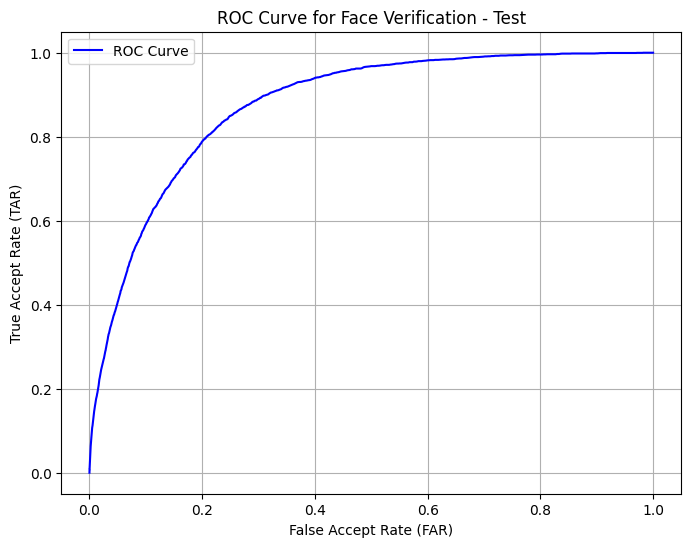

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▄▃▃▂▂▁▁▁
validation_auc,▁▄▅▅▇▇▇▇█▇
validation_eer,█▅▅▅▂▃▂▂▁▂
validation_loss,█▅▄▄▂▂▂▂▁▂
validation_tar_at_far_1,▁▂▆▃▅█▄▄█▃
validation_tar_at_far_10,▁▃▅▅▆▇█▆█▇


In [17]:
sweep_id = wandb.sweep(sweep_config, project="nsiete-project-3")
wandb.agent(sweep_id, function=sweep_shadow, count=5)
wandb.finish()

Create sweep with ID: 976owg35
Sweep URL: https://wandb.ai/xmagyarova-stu/nsiete-project-3/sweeps/976owg35


wandb: Agent Starting Run: zhzmkjg3 with config:
wandb: 	batch_size: 37
wandb: 	embedding_size: 172
wandb: 	lr: 0.0005766418593066617
wandb: 	margin: 0.9601227369684427
wandb: 	weight_decay: 0.6643469573014968


--- Epoch 1 ---


100%|██████████| 24/24 [00:05<00:00,  4.70it/s, mean_loss=0.604189183562994] 


TAR@FAR=10%: 0.3005649717593156
TAR@FAR=5%: 0.19661016950060328
TAR@FAR=1%: 0.047457627129407265
AUC: 0.7350180344036901
EER: 0.32881355931831846
EER Threshold 0.9884164333343506
--- Epoch 2 ---


...

TAR@FAR=10%: 0.46553672316988093
TAR@FAR=5%: 0.23050847458496604
TAR@FAR=1%: 0.057627118654716036
AUC: 0.8222177535118091
EER: 0.25254237287850234
EER Threshold 0.26452454924583435
--- Epoch 9 ---


100%|██████████| 24/24 [00:05<00:00,  4.73it/s, mean_loss=0.5825533146659533]


TAR@FAR=10%: 0.4056497175208401
TAR@FAR=5%: 0.24180790961308696
TAR@FAR=1%: 0.058757062157528184
AUC: 0.8201940693853267
EER: 0.2672316384150595
EER Threshold 0.18511690199375153
--- Epoch 10 ---


100%|██████████| 24/24 [00:05<00:00,  4.69it/s, mean_loss=0.46840785381694633]


TAR@FAR=10%: 0.477966101700814
TAR@FAR=5%: 0.30621468927337614
TAR@FAR=1%: 0.05310734464346767
AUC: 0.8284247821432882
EER: 0.2497175141214721
EER Threshold 0.6110748052597046
--- Test ---
TAR@FAR=10%: 0.4103343465063516
TAR@FAR=5%: 0.25653495440955454
TAR@FAR=1%: 0.07993920972924029
AUC: 0.8067830629540632
EER: 0.26685677617139925
EER Threshold 0.7883518099415678


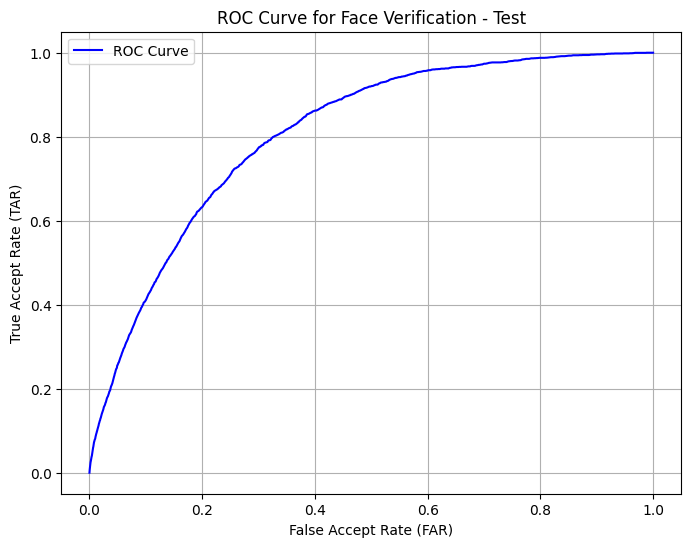

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▆▅▄▃▃▂▂▁
validation_auc,▁▄▇▇▄█▇▇▇█
validation_eer,█▅▂▁▅▂▃▂▃▂
validation_loss,█▄▁▂▅▄▃▅▇▁
validation_tar_at_far_1,▁▄▄▅▅█▅▂▂▂
validation_tar_at_far_10,▁▃▅▆▄█▇▆▄▆


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: rr9dqmnu with config:
wandb: 	batch_size: 53
wandb: 	embedding_size: 102
wandb: 	lr: 0.0007585815420565159
wandb: 	margin: 0.7309087703710409
wandb: 	weight_decay: 0.7667778227130992


--- Epoch 1 ---


100%|██████████| 17/17 [00:05<00:00,  3.33it/s, mean_loss=0.4261067632366629] 


TAR@FAR=10%: 0.3344632768436784
TAR@FAR=5%: 0.17175141243873726
TAR@FAR=1%: 0.04971751413503145
AUC: 0.7573960228483948
EER: 0.30677966101348275
EER Threshold 0.8981336355209351
--- Epoch 2 ---


...

TAR@FAR=10%: 0.4564971751473842
TAR@FAR=5%: 0.32768361582680583
TAR@FAR=1%: 0.09830508475595134
AUC: 0.819398001844089
EER: 0.2593220338953749
EER Threshold 0.979963481426239
--- Epoch 9 ---


100%|██████████| 17/17 [00:04<00:00,  3.48it/s, mean_loss=0.41154705075656667]


TAR@FAR=10%: 0.4158192090461489
TAR@FAR=5%: 0.2621468926637046
TAR@FAR=1%: 0.029378531084413795
AUC: 0.8213508251068367
EER: 0.25028248587287816
EER Threshold 0.20852287113666534
--- Epoch 10 ---


100%|██████████| 17/17 [00:04<00:00,  3.48it/s, mean_loss=0.3189932081629248] 


TAR@FAR=10%: 0.5299435028301701
TAR@FAR=5%: 0.33333333334086634
TAR@FAR=1%: 0.06553672317440074
AUC: 0.8385176673293092
EER: 0.23220338982788472
EER Threshold 0.60934978723526
--- Test ---
TAR@FAR=10%: 0.4413373860199351
TAR@FAR=5%: 0.2738601823730278
TAR@FAR=1%: 0.08054711246480073
AUC: 0.811372488247512
EER: 0.2616239945419902
EER Threshold 0.8288578130043781


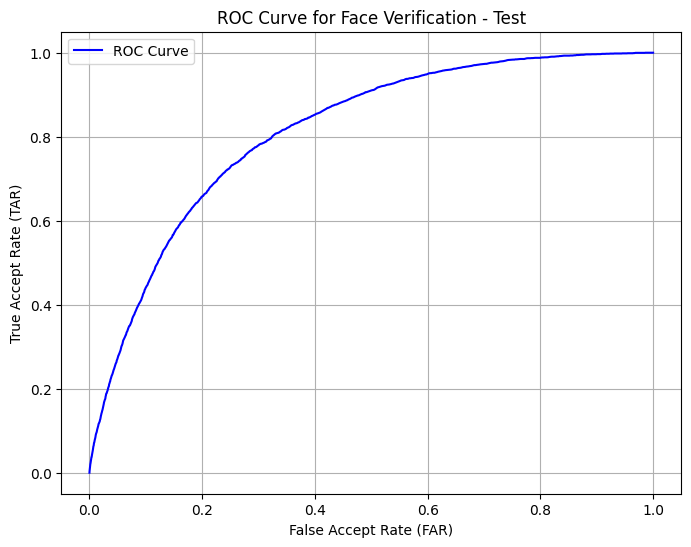

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▆▃▂▂▁▁
validation_auc,▅▅▆▁▇▆▇▇▇█
validation_eer,▄▄▄█▃▄▃▂▂▁
validation_loss,▃▃▃█▂▃▂▁▃▁
validation_tar_at_far_1,▄▅▅▁▆▅█▇▃▅
validation_tar_at_far_10,▂▂▂▁▆▃▆▆▄█


wandb: Agent Starting Run: bnw4cl0j with config:
wandb: 	batch_size: 25
wandb: 	embedding_size: 91
wandb: 	lr: 0.00087888731023522
wandb: 	margin: 0.944546034902546
wandb: 	weight_decay: 0.429766607296723


--- Epoch 1 ---


100%|██████████| 36/36 [00:05<00:00,  6.77it/s, mean_loss=0.61733338319593]  


TAR@FAR=10%: 0.33333333334086634
TAR@FAR=5%: 0.2135593220427846
TAR@FAR=1%: 0.07344632769408532
AUC: 0.7288167512476491
EER: 0.3508474576231543
EER Threshold 0.6815374493598938
--- Epoch 2 ---


...

TAR@FAR=10%: 0.429378531079894
TAR@FAR=5%: 0.22033898305965716
TAR@FAR=1%: 0.08248587571658206
AUC: 0.8118816431989143
EER: 0.2615819209009991
EER Threshold 0.6649509072303772
--- Epoch 9 ---


100%|██████████| 36/36 [00:05<00:00,  7.11it/s, mean_loss=0.6397315238912901]


TAR@FAR=10%: 0.4372881355995787
TAR@FAR=5%: 0.26553672317214083
TAR@FAR=1%: 0.07909604520814584
AUC: 0.80650770850594
EER: 0.2723163841777139
EER Threshold 0.09261588007211685
--- Epoch 10 ---


100%|██████████| 36/36 [00:05<00:00,  7.12it/s, mean_loss=0.4866849063999123] 


TAR@FAR=10%: 0.39548022599553134
TAR@FAR=5%: 0.266666666674953
TAR@FAR=1%: 0.025988700575977575
AUC: 0.8104791088058917
EER: 0.26553672316084137
EER Threshold 0.42437127232551575
--- Test ---
TAR@FAR=10%: 0.3349544072968542
TAR@FAR=5%: 0.20607902735803618
TAR@FAR=1%: 0.05987841945574501
AUC: 0.7605234412120091
EER: 0.3144807813192927
EER Threshold 0.7596522975373674


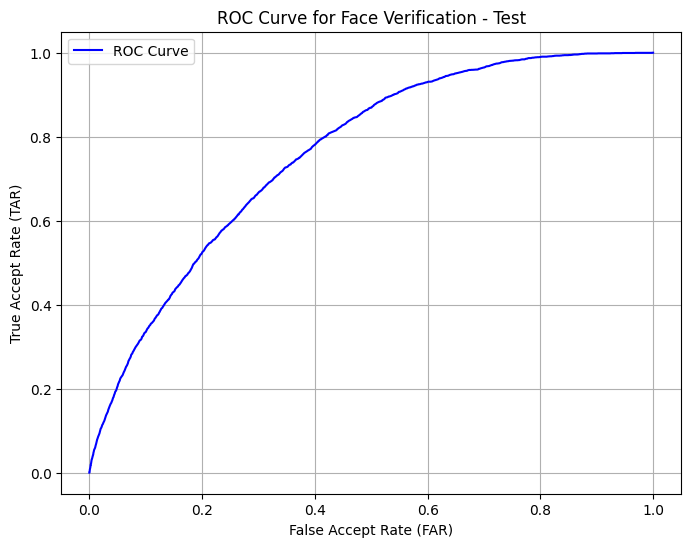

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▅▄▂▂▁▁
validation_auc,▃▁▅▃▆▇▅███
validation_eer,██▃▆▃▂▅▁▂▁
validation_loss,▇█▃▆▂▅▄▁█▂
validation_tar_at_far_1,▄▂▄▂█▂▃▅▄▁
validation_tar_at_far_10,▃▁▄▂▇▆▄██▆


wandb: Agent Starting Run: beznaomc with config:
wandb: 	batch_size: 50
wandb: 	embedding_size: 74
wandb: 	lr: 0.0007224058969536776
wandb: 	margin: 0.8005094344633139
wandb: 	weight_decay: 0.7957377598209726


--- Epoch 1 ---


100%|██████████| 18/18 [00:04<00:00,  3.66it/s, mean_loss=0.4638171055250698] 


TAR@FAR=10%: 0.3220338983127454
TAR@FAR=5%: 0.2079096045287242
TAR@FAR=1%: 0.04180790961534686
AUC: 0.7563739666065973
EER: 0.3062146892620767
EER Threshold 0.8703597187995911
--- Epoch 2 ---


...

TAR@FAR=10%: 0.4564971751473842
TAR@FAR=5%: 0.3005649717593156
TAR@FAR=1%: 0.07683615820252165
AUC: 0.7782214561525302
EER: 0.30112994349942224
EER Threshold 0.21415843069553375
--- Epoch 9 ---


100%|██████████| 18/18 [00:04<00:00,  3.66it/s, mean_loss=0.42882566899061203]


TAR@FAR=10%: 0.4463276836220754
TAR@FAR=5%: 0.29604519774806726
TAR@FAR=1%: 0.04858757063221941
AUC: 0.8159979571571346
EER: 0.26949152542068366
EER Threshold 0.26137104630470276
--- Epoch 10 ---


100%|██████████| 18/18 [00:04<00:00,  3.66it/s, mean_loss=0.41127825445599026]


TAR@FAR=10%: 0.4158192090461489
TAR@FAR=5%: 0.305084745770564
TAR@FAR=1%: 0.09378531074470298
AUC: 0.8140068307248007
EER: 0.27118644067490183
EER Threshold 0.3467758893966675
--- Test ---
TAR@FAR=10%: 0.36808510638489944
TAR@FAR=5%: 0.221580547114828
TAR@FAR=1%: 0.05775075988128342
AUC: 0.7758994930318011
EER: 0.30190264665341526
EER Threshold 0.631753071933776


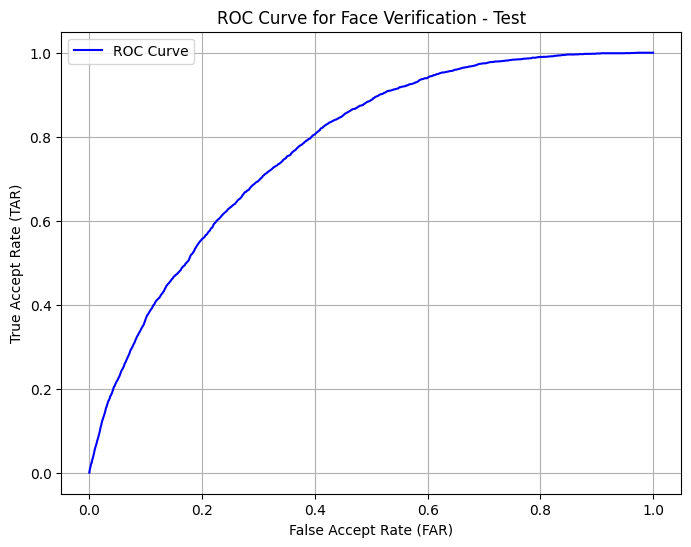

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▆▅▅▃▂▂▁▁
validation_auc,▁▇▅▄▆▆▇▄██
validation_eer,█▁▁▃▄▅▃▇▁▂
validation_loss,▆▃▃▄▂▃▁█▄▃
validation_tar_at_far_1,▁▆▃▃██▃▄▂▆
validation_tar_at_far_10,▁▇▅▃▆███▇▆


wandb: Agent Starting Run: c0i6nd85 with config:
wandb: 	batch_size: 26
wandb: 	embedding_size: 243
wandb: 	lr: 0.0006468830950755344
wandb: 	margin: 0.32462049450132946
wandb: 	weight_decay: 0.22661189006976917


--- Epoch 1 ---


100%|██████████| 35/35 [00:04<00:00,  7.03it/s, mean_loss=0.1885326642010893] 


TAR@FAR=10%: 0.36610169492241695
TAR@FAR=5%: 0.21468926554559675
TAR@FAR=1%: 0.0757062146997095
AUC: 0.7497404960203895
EER: 0.3214689265500399
EER Threshold 0.28005343675613403
--- Epoch 2 ---


...

TAR@FAR=10%: 0.3977401130011555
TAR@FAR=5%: 0.266666666674953
TAR@FAR=1%: 0.08700564972783043
AUC: 0.7749344058158558
EER: 0.29378531073114367
EER Threshold 0.1968071460723877
--- Epoch 9 ---


100%|██████████| 35/35 [00:04<00:00,  7.03it/s, mean_loss=0.16756168603897095]


TAR@FAR=10%: 0.3943502824927192
TAR@FAR=5%: 0.266666666674953
TAR@FAR=1%: 0.07118644068846114
AUC: 0.7826633470522351
EER: 0.28531073446005295
EER Threshold 0.5467416644096375
--- Epoch 10 ---


100%|██████████| 35/35 [00:05<00:00,  6.92it/s, mean_loss=0.15401151339922634]


TAR@FAR=10%: 0.4451977401192633
TAR@FAR=5%: 0.2734463276918254
TAR@FAR=1%: 0.07457627119689747
AUC: 0.793763605598379
EER: 0.2723163841777139
EER Threshold 0.5654118657112122
--- Test ---
TAR@FAR=10%: 0.321580547114524
TAR@FAR=5%: 0.1987841945313107
TAR@FAR=1%: 0.06170212766242644
AUC: 0.7414667765326248
EER: 0.3253038342846897
EER Threshold 0.7792944477104747


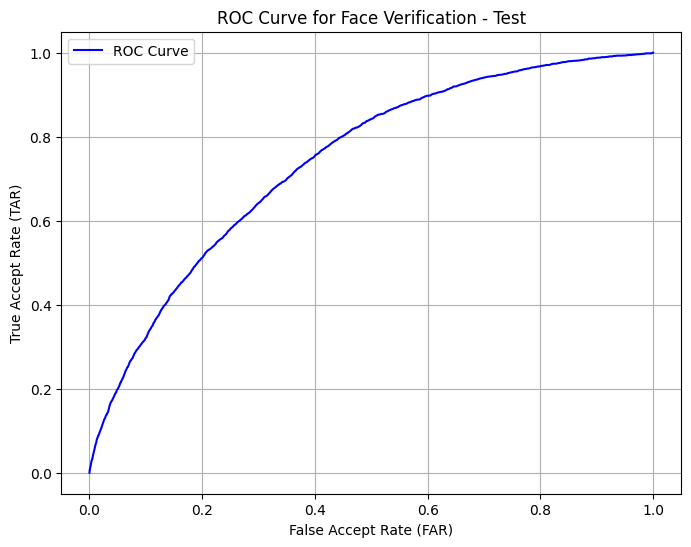

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▃▃▂▂▂▁▁▁
validation_auc,▃▁▃▆▄▇▄▆▇█
validation_eer,▆█▆▂▄▃▆▃▂▁
validation_loss,▆█▆▄▆▅▇▅▃▁
validation_tar_at_far_1,▆▅▆▁▃█▅▇▅▆
validation_tar_at_far_10,▃▁▄▃▂▆▆▅▅█


In [18]:
sweep_id = wandb.sweep(sweep_config, project="nsiete-project-3")
wandb.agent(sweep_id, function=sweep_triplet, count=5)
wandb.finish()

### 6.2. Only valid classes

In [19]:
train_subset2, val_subset2, test_subset2 = split_dataset(full_dataset, 2)
test_pairs2 = create_pairs(test_subset2)

train_dataset_valid_only = OnlineTripletDataset(train_subset2)
val_dataset_valid_only = OnlineTripletDataset(val_subset2)

Number of same pairs: 3412
Number of different pairs: 269279
Initialized OnlineTripletDataset with 1344 valid classes.
Initialized OnlineTripletDataset with 168 valid classes.


In [20]:
def sweep_valid_only():
    wandb.init()
    config = wandb.config
    train_loader = DataLoader(train_dataset_valid_only, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset_valid_only, batch_size=config.batch_size, shuffle=False)
    model: nn.Module = NeuralNet(config.embedding_size).to(device)
    loss = ShadowLoss(margin=config.margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(model, loss, optimizer, scheduler, 10, train_loader, val_loader)
    print("--- Test ---")
    test(model, test_subset2, test_pairs2)

Create sweep with ID: 4jikkwfx
Sweep URL: https://wandb.ai/xmagyarova-stu/nsiete-project-3/sweeps/4jikkwfx


wandb: Agent Starting Run: 8uy8obuh with config:
wandb: 	batch_size: 38
wandb: 	embedding_size: 138
wandb: 	lr: 0.00091119953909388
wandb: 	margin: 0.6990448652486768
wandb: 	weight_decay: 0.9790946909949976


--- Epoch 1 ---


100%|██████████| 22/22 [00:04<00:00,  4.66it/s, mean_loss=0.478852242231369]  


TAR@FAR=10%: 0.2975903614542459
TAR@FAR=5%: 0.1831325301303237
TAR@FAR=1%: 0.07108433736058939
AUC: 0.7089889679148219
EER: 0.3415662650561257
EER Threshold 0.7251052856445312
--- Epoch 2 ---


...

TAR@FAR=10%: 0.47951807229542753
TAR@FAR=5%: 0.35662650603184787
TAR@FAR=1%: 0.13373493976947304
AUC: 0.8281448686232294
EER: 0.24819277108134707
EER Threshold 1.1603131294250488
--- Epoch 9 ---


100%|██████████| 22/22 [00:04<00:00,  4.46it/s, mean_loss=0.2914871908724308] 


TAR@FAR=10%: 0.5072289156685876
TAR@FAR=5%: 0.35060240964637834
TAR@FAR=1%: 0.12048192772143995
AUC: 0.8454746697550517
EER: 0.24096385541878357
EER Threshold 0.7970741391181946
--- Epoch 10 ---


100%|██████████| 22/22 [00:04<00:00,  4.73it/s, mean_loss=0.2820065685293891] 


TAR@FAR=10%: 0.5542168674752503
TAR@FAR=5%: 0.3662650602485992
TAR@FAR=1%: 0.1265060241069096
AUC: 0.8533096240297939
EER: 0.22650602409365655
EER Threshold 0.9403943419456482
--- Test ---
TAR@FAR=10%: 0.5978898007045783
TAR@FAR=5%: 0.38833528722336363
TAR@FAR=1%: 0.11694021102251773
AUC: 0.8794926715143052
EER: 0.19383978327717732
EER Threshold 0.9360671437739788


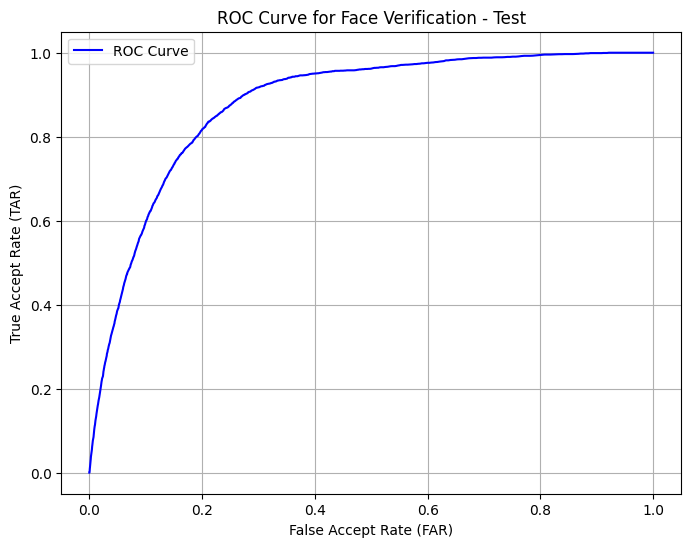

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▄▃▃▂▂▁
validation_auc,▁▃▄▆▅▆▇▇██
validation_eer,█▆▅▃▃▃▂▂▂▁
validation_loss,█▆▅▃▄▃▂▂▁▁
validation_tar_at_far_1,▃▁▂▅▁▂▅█▇▇
validation_tar_at_far_10,▁▂▃▅▆▅▆▆▇█


wandb: Agent Starting Run: klxnd2a5 with config:
wandb: 	batch_size: 50
wandb: 	embedding_size: 232
wandb: 	lr: 0.0007278967027688243
wandb: 	margin: 0.7436453775835431
wandb: 	weight_decay: 0.6581442379140964


--- Epoch 1 ---


100%|██████████| 17/17 [00:04<00:00,  3.68it/s, mean_loss=0.4793655661975636] 


TAR@FAR=10%: 0.34216867470672085
TAR@FAR=5%: 0.19879518073254465
TAR@FAR=1%: 0.05180722892708667
AUC: 0.7285375235828078
EER: 0.3325301204779213
EER Threshold 1.027307391166687
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5915662650651619
TAR@FAR=5%: 0.3891566265133837
TAR@FAR=1%: 0.1132530120588765
AUC: 0.8749245173374457
EER: 0.19759036144340253
EER Threshold 1.0571064949035645
--- Epoch 9 ---


100%|██████████| 17/17 [00:04<00:00,  3.74it/s, mean_loss=0.2780367241186254] 


TAR@FAR=10%: 0.5409638554272174
TAR@FAR=5%: 0.34698795181509656
TAR@FAR=1%: 0.11084337350468865
AUC: 0.8647633909042458
EER: 0.21626506023835826
EER Threshold 0.7801330089569092
--- Epoch 10 ---


100%|██████████| 17/17 [00:04<00:00,  3.72it/s, mean_loss=0.2584927862181383] 


TAR@FAR=10%: 0.6084337349444767
TAR@FAR=5%: 0.36987951807988095
TAR@FAR=1%: 0.16987951808229063
AUC: 0.8775591522626253
EER: 0.1981927710819495
EER Threshold 0.963933527469635
--- Test ---
TAR@FAR=10%: 0.5981828839402163
TAR@FAR=5%: 0.39917936694197187
TAR@FAR=1%: 0.11987104337889831
AUC: 0.8792620901869042
EER: 0.18940977312202098
EER Threshold 0.9669229924544558


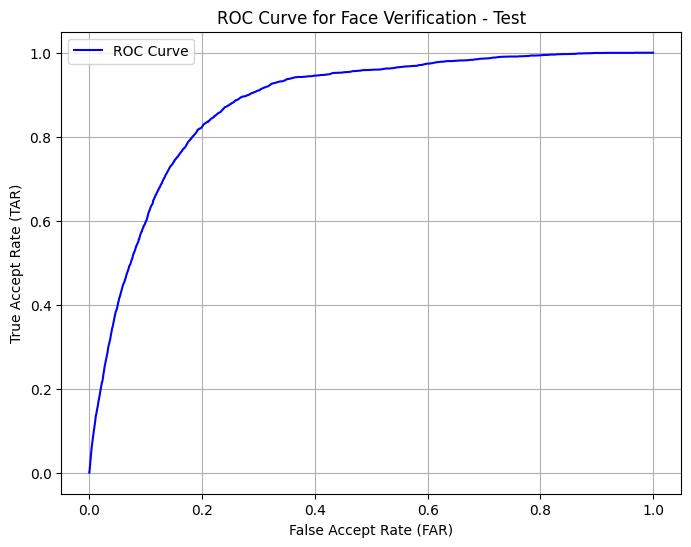

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▄▄▃▃▂▂▁▁
validation_auc,▁▄▃▅▆▇▇█▇█
validation_eer,█▅▆▄▃▂▂▁▂▁
validation_loss,█▅▆▄▃▂▂▁▂▁
validation_tar_at_far_1,▁▂▁▄▂▃▃▅▅█
validation_tar_at_far_10,▁▄▂▃▅▇▆█▆█


wandb: Agent Starting Run: 7zjjgifu with config:
wandb: 	batch_size: 51
wandb: 	embedding_size: 248
wandb: 	lr: 0.0007598868017006672
wandb: 	margin: 0.7288840443137728
wandb: 	weight_decay: 0.7103652241623581


--- Epoch 1 ---


100%|██████████| 17/17 [00:04<00:00,  3.71it/s, mean_loss=0.5030927675611833]


TAR@FAR=10%: 0.2614457831414284
TAR@FAR=5%: 0.11686746989015828
TAR@FAR=1%: 0.018072289168456934
AUC: 0.6979176948711054
EER: 0.34939759035723617
EER Threshold 1.0637986660003662
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5289156626562781
TAR@FAR=5%: 0.3433734939838148
TAR@FAR=1%: 0.1228915662756278
AUC: 0.8526789083961903
EER: 0.21987951806964
EER Threshold 1.016981840133667
--- Epoch 9 ---


100%|██████████| 17/17 [00:04<00:00,  3.76it/s, mean_loss=0.3091544167083852] 


TAR@FAR=10%: 0.5373493975959356
TAR@FAR=5%: 0.30963855422518505
TAR@FAR=1%: 0.07710843374605891
AUC: 0.8414857018352756
EER: 0.2313253012020322
EER Threshold 0.9945259690284729
--- Epoch 10 ---


100%|██████████| 17/17 [00:04<00:00,  3.61it/s, mean_loss=0.30848447540227103]


TAR@FAR=10%: 0.544578313258499
TAR@FAR=5%: 0.3662650602485992
TAR@FAR=1%: 0.0855421686857164
AUC: 0.8454006386910384
EER: 0.23192771084057917
EER Threshold 1.073017954826355
--- Test ---
TAR@FAR=10%: 0.5492379835886598
TAR@FAR=5%: 0.3616647127802999
TAR@FAR=1%: 0.12192262602836479
AUC: 0.8659432231104061
EER: 0.20860680995153313
EER Threshold 1.0041011833885052


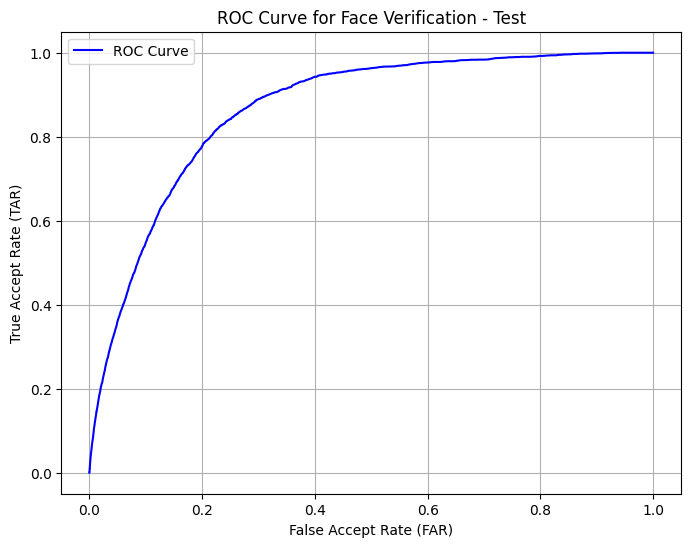

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▄▄▃▂▂▁▁
validation_auc,▁▅▆▇▇▇▇█▇█
validation_eer,█▄▃▃▃▂▂▁▂▂
validation_loss,█▄▃▂▃▂▂▁▂▂
validation_tar_at_far_1,▁█▅▃▇▆▅▇▄▅
validation_tar_at_far_10,▁▆▅▆▆█▇███


wandb: Agent Starting Run: tuso1bae with config:
wandb: 	batch_size: 28
wandb: 	embedding_size: 151
wandb: 	lr: 0.00099177490338719
wandb: 	margin: 0.23360738044625673
wandb: 	weight_decay: 0.7925915071032777


--- Epoch 1 ---


100%|██████████| 30/30 [00:04<00:00,  6.37it/s, mean_loss=0.14965806926290195]


TAR@FAR=10%: 0.3674698795256931
TAR@FAR=5%: 0.20240963856382643
TAR@FAR=1%: 0.053012048204180595
AUC: 0.7336913920686758
EER: 0.3253012048153578
EER Threshold 0.37655261158943176
--- Epoch 2 ---


...

TAR@FAR=10%: 0.4674698795244884
TAR@FAR=5%: 0.3168674698877486
TAR@FAR=1%: 0.06626506025221368
AUC: 0.8319625489831317
EER: 0.2421686746958775
EER Threshold 0.4063689112663269
--- Epoch 9 ---


100%|██████████| 30/30 [00:04<00:00,  6.53it/s, mean_loss=0.10178283452987671]


TAR@FAR=10%: 0.4698795180786761
TAR@FAR=5%: 0.2843373494062128
TAR@FAR=1%: 0.06987951808349546
AUC: 0.8302765277899657
EER: 0.2403614457802366
EER Threshold 0.285800039768219
--- Epoch 10 ---


100%|██████████| 30/30 [00:04<00:00,  6.22it/s, mean_loss=0.09391173925250769]


TAR@FAR=10%: 0.5578313253065321
TAR@FAR=5%: 0.3337349397670635
TAR@FAR=1%: 0.10843373495050079
AUC: 0.8486921178606499
EER: 0.22831325300929745
EER Threshold 0.3624572157859802
--- Test ---
TAR@FAR=10%: 0.5430832356402606
TAR@FAR=5%: 0.33294255568776976
TAR@FAR=1%: 0.08206330598158829
AUC: 0.864945123944231
EER: 0.2066898961096163
EER Threshold 0.581315509702738


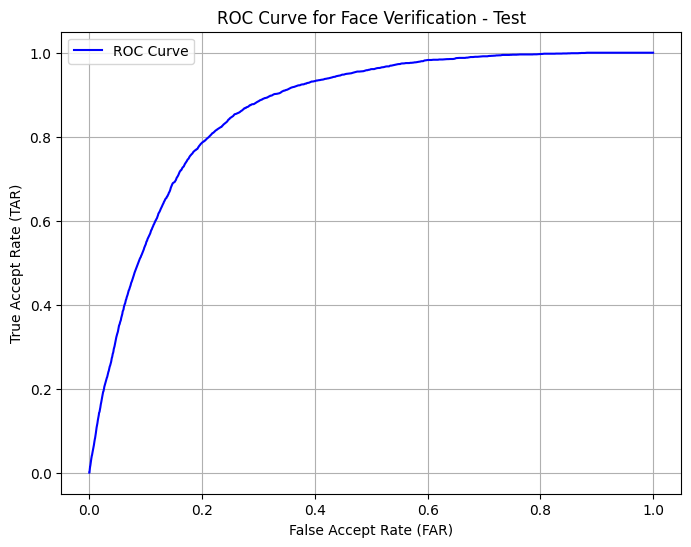

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▆▅▄▄▃▂▁▁
validation_auc,▁▃▄▅▆▆▆▇▇█
validation_eer,█▇▅▄▄▃▃▂▂▁
validation_loss,█▆▅▄▃▃▃▂▂▁
validation_tar_at_far_1,▁▃▄▂▅▂▄▃▃█
validation_tar_at_far_10,▂▁▂▄▄▆▄▅▅█


wandb: Agent Starting Run: xclz5gak with config:
wandb: 	batch_size: 41
wandb: 	embedding_size: 213
wandb: 	lr: 0.0009913848027540803
wandb: 	margin: 0.03293755868160231
wandb: 	weight_decay: 0.4300167839022665


--- Epoch 1 ---


100%|██████████| 21/21 [00:04<00:00,  4.47it/s, mean_loss=0.016941588682432968]


TAR@FAR=10%: 0.43373493976585864
TAR@FAR=5%: 0.2566265060330527
TAR@FAR=1%: 0.10240963856503127
AUC: 0.8029815648061556
EER: 0.26686746987630283
EER Threshold 0.08241530507802963
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5325301204875599
TAR@FAR=5%: 0.427710843380389
TAR@FAR=1%: 0.09397590362537378
AUC: 0.8559805486922352
EER: 0.22048192770818698
EER Threshold 0.13616876304149628
--- Epoch 9 ---


100%|██████████| 21/21 [00:04<00:00,  4.50it/s, mean_loss=0.01103635452732089] 


TAR@FAR=10%: 0.6012048192819133
TAR@FAR=5%: 0.40240963856141676
TAR@FAR=1%: 0.16626506025100884
AUC: 0.8635520394744594
EER: 0.21144578312998258
EER Threshold 0.10118015110492706
--- Epoch 10 ---


100%|██████████| 21/21 [00:04<00:00,  4.57it/s, mean_loss=0.012553266482427716]


TAR@FAR=10%: 0.6084337349444767
TAR@FAR=5%: 0.40602409639269854
TAR@FAR=1%: 0.14698795181750612
AUC: 0.8666773116474136
EER: 0.20240963855177818
EER Threshold 0.14012813568115234
--- Test ---
TAR@FAR=10%: 0.6049237983598919
TAR@FAR=5%: 0.40738569753983767
TAR@FAR=1%: 0.1324736225113351
AUC: 0.8751500549730176
EER: 0.19749535717961694
EER Threshold 0.362692139779886


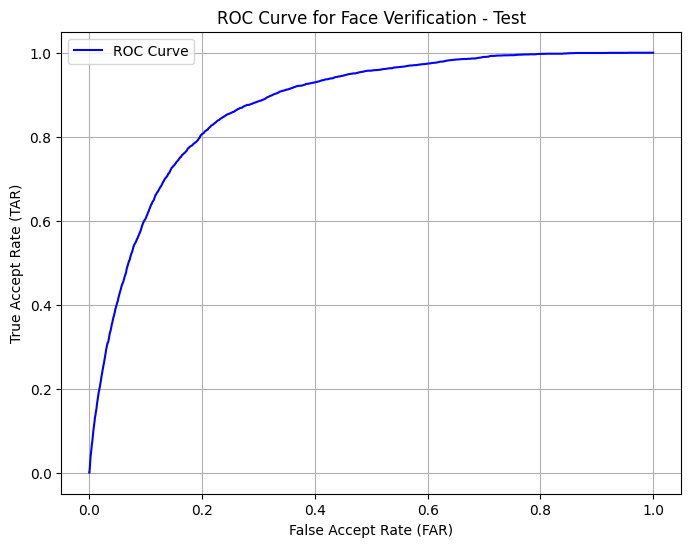

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▅▄▃▃▂▂▁▁
validation_auc,▂▂▅▁█▅▇▇██
validation_eer,██▅█▂▅▃▃▂▁
validation_loss,▇▅▃▇▂█▂▃▁▂
validation_tar_at_far_1,▃▃▆▁▆▇█▃█▇
validation_tar_at_far_10,▃▃▆▁▆▅▇▆██


In [21]:
sweep_id = wandb.sweep(sweep_config, project="nsiete-project-3")
wandb.agent(sweep_id, function=sweep_valid_only, count=5)
wandb.finish()

### 6.3. Simplified ResNet18 

In [17]:
def sweep_simplified():
    wandb.init()
    config = wandb.config
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
    model: nn.Module = SimplifiedNeuralNet(config.embedding_size).to(device)
    loss = ShadowLoss(margin=config.margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(model, loss, optimizer, scheduler, 10, train_loader, val_loader)
    print("--- Test ---")
    test(model, test_subset, test_pairs)

Create sweep with ID: 5vhll9hc
Sweep URL: https://wandb.ai/xmagyarova-stu/nsiete-project-3/sweeps/5vhll9hc


wandb: Agent Starting Run: iii6g91r with config:
wandb: 	batch_size: 53
wandb: 	embedding_size: 164
wandb: 	lr: 0.00010434959467286711
wandb: 	margin: 0.602501015647548
wandb: 	weight_decay: 0.9492008506893712
wandb: Currently logged in as: xmagyarova (xmagyarova-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--- Epoch 1 ---


100%|██████████| 17/17 [00:05<00:00,  3.03it/s, mean_loss=0.5434116528314703]


TAR@FAR=10%: 0.1887005649809187
TAR@FAR=5%: 0.1242937853206294
TAR@FAR=1%: 0.04971751413503145
AUC: 0.5809020396419394
EER: 0.4519774011248364
EER Threshold 0.7245376706123352
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5016949152598679
TAR@FAR=5%: 0.3457627118717993
TAR@FAR=1%: 0.11638418080094481
AUC: 0.8297194292753092
EER: 0.2519774011270963
EER Threshold 0.7716593146324158
--- Epoch 9 ---


100%|██████████| 17/17 [00:05<00:00,  3.09it/s, mean_loss=0.353584926794557]  


TAR@FAR=10%: 0.5581920904004725
TAR@FAR=5%: 0.40338983051521593
TAR@FAR=1%: 0.1378531073543745
AUC: 0.8546873503702155
EER: 0.2344632768335089
EER Threshold 0.5991071462631226
--- Epoch 10 ---


100%|██████████| 17/17 [00:05<00:00,  3.10it/s, mean_loss=0.301922462442342]  


TAR@FAR=10%: 0.5231638418132976
TAR@FAR=5%: 0.35819209040273225
TAR@FAR=1%: 0.118644067806569
AUC: 0.8333058827209172
EER: 0.24802259886725397
EER Threshold 1.0451892614364624
--- Test ---
TAR@FAR=10%: 0.41155015197747247
TAR@FAR=5%: 0.27537993921192894
TAR@FAR=1%: 0.09604863222159254
AUC: 0.7851280255418426
EER: 0.28500948567196394
EER Threshold 1.0590938469907782


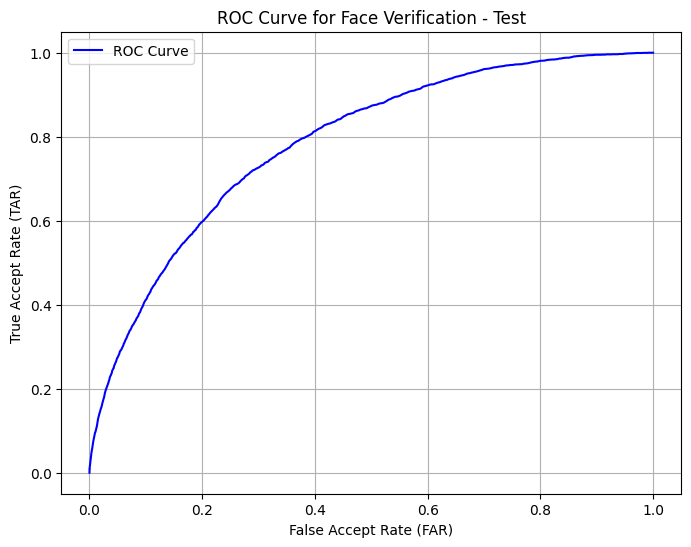

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▆▅▅▅▄▃▂▂▁
validation_auc,▁▄▅▆▆▇▆▇█▇
validation_eer,█▅▄▃▃▂▃▂▁▁
validation_loss,█▄▃▂▂▁▁▂▂▁
validation_tar_at_far_1,▁▂▁▄▅█▄▆█▆
validation_tar_at_far_10,▁▃▄▄▅▆▅▇█▇


wandb: Agent Starting Run: 36w5gqta with config:
wandb: 	batch_size: 54
wandb: 	embedding_size: 138
wandb: 	lr: 6.881138913488858e-05
wandb: 	margin: 0.8499041972451379
wandb: 	weight_decay: 0.6486084685111939


--- Epoch 1 ---


100%|██████████| 17/17 [00:05<00:00,  3.10it/s, mean_loss=0.695245995241053] 


TAR@FAR=10%: 0.2293785310821539
TAR@FAR=5%: 0.12655367232625359
TAR@FAR=1%: 0.025988700575977575
AUC: 0.6379475884931511
EER: 0.39830508474126214
EER Threshold 0.8439227938652039
--- Epoch 2 ---


...

TAR@FAR=10%: 0.5322033898357943
TAR@FAR=5%: 0.33672316384930256
TAR@FAR=1%: 0.1649717514218647
AUC: 0.8303827124953139
EER: 0.23954802259616328
EER Threshold 1.1223266124725342
--- Epoch 9 ---


100%|██████████| 17/17 [00:05<00:00,  3.10it/s, mean_loss=0.3977453656056348] 


TAR@FAR=10%: 0.503954802265492
TAR@FAR=5%: 0.36384180791679277
TAR@FAR=1%: 0.1322033898403141
AUC: 0.8343956078956509
EER: 0.24067796609897538
EER Threshold 1.003124713897705
--- Epoch 10 ---


100%|██████████| 17/17 [00:05<00:00,  3.10it/s, mean_loss=0.371059635106255]  


TAR@FAR=10%: 0.5548022598920361
TAR@FAR=5%: 0.4214689265602094
TAR@FAR=1%: 0.13333333334312614
AUC: 0.8482664623752123
EER: 0.22994350282226053
EER Threshold 1.0490325689315796
--- Test ---
TAR@FAR=10%: 0.3838905775094714
TAR@FAR=5%: 0.2620060790295987
TAR@FAR=1%: 0.09088145896932864
AUC: 0.7658726713301356
EER: 0.30191045835447416
EER Threshold 1.1519324764072358


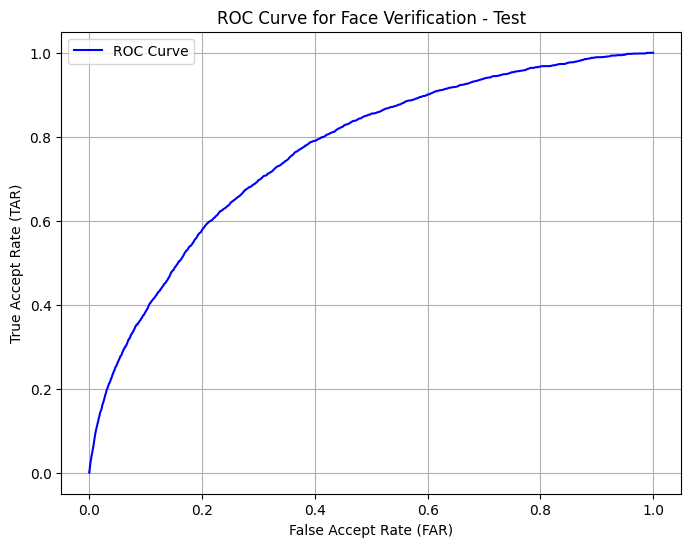

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▄▃▃▂▂▁▁▁
validation_auc,▁▃▃▅▆▆▇▇██
validation_eer,█▅▆▄▃▄▂▁▁▁
validation_loss,█▆▅▄▃▃▂▂▂▁
validation_tar_at_far_1,▁▃▃▄▃▅▄█▆▆
validation_tar_at_far_10,▁▂▂▅▅▅▆█▇█


wandb: Agent Starting Run: wckby7bs with config:
wandb: 	batch_size: 44
wandb: 	embedding_size: 200
wandb: 	lr: 0.00046306588831090576
wandb: 	margin: 0.2039572646961787
wandb: 	weight_decay: 0.10017781827245564


--- Epoch 1 ---


100%|██████████| 21/21 [00:05<00:00,  3.86it/s, mean_loss=0.18441714772156306]


TAR@FAR=10%: 0.18192090396404614
TAR@FAR=5%: 0.09378531074470298
TAR@FAR=1%: 0.019209039559105023
AUC: 0.5746516007515958
EER: 0.45593220338467877
EER Threshold 0.18514151871204376
--- Epoch 2 ---


...

TAR@FAR=10%: 0.32316384181555746
TAR@FAR=5%: 0.2293785310821539
TAR@FAR=1%: 0.05988700566034022
AUC: 0.7269903284445367
EER: 0.3384180790922212
EER Threshold 0.7613785862922668
--- Epoch 9 ---


100%|██████████| 21/21 [00:05<00:00,  3.86it/s, mean_loss=0.10547436348029546]


TAR@FAR=10%: 0.3785310734533499
TAR@FAR=5%: 0.23276836159059022
TAR@FAR=1%: 0.08022598871095787
AUC: 0.7692910721634569
EER: 0.29604519773676785
EER Threshold 0.8206449151039124
--- Epoch 10 ---


100%|██████████| 21/21 [00:05<00:00,  3.74it/s, mean_loss=0.11292105487414769]


TAR@FAR=10%: 0.4248587570686456
TAR@FAR=5%: 0.2892655367311947
TAR@FAR=1%: 0.09039548023626676
AUC: 0.7785438411632157
EER: 0.29604519773676785
EER Threshold 1.2348726987838745
--- Test ---
TAR@FAR=10%: 0.3653495440748773
TAR@FAR=5%: 0.23069908814823492
TAR@FAR=1%: 0.06079027355908573
AUC: 0.737372201748491
EER: 0.324100938873049
EER Threshold 1.150627390549586


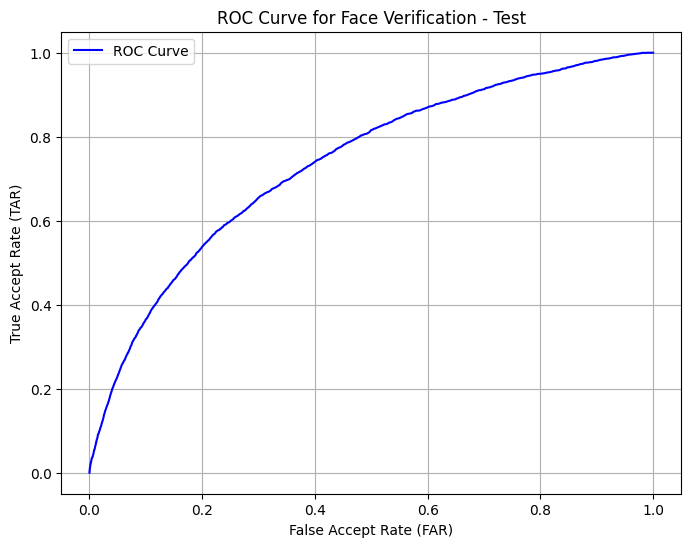

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,██▇▆▆▅▄▄▂▁
validation_auc,▁▂▃▄▅▆▆▆██
validation_eer,██▆▅▄▃▃▃▁▁
validation_loss,██▆▅▄▄▃▄▁▂
validation_tar_at_far_1,▁▂▁▂▄▄█▅▇█
validation_tar_at_far_10,▂▁▂▄▅▅▅▅▇█


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 1a3taa8w with config:
wandb: 	batch_size: 55
wandb: 	embedding_size: 183
wandb: 	lr: 5.5094568256143216e-05
wandb: 	margin: 0.9498080639645982
wandb: 	weight_decay: 0.6794216096738307


--- Epoch 1 ---


100%|██████████| 17/17 [00:05<00:00,  3.13it/s, mean_loss=0.7782471846131718]


TAR@FAR=10%: 0.2214689265624693
TAR@FAR=5%: 0.118644067806569
TAR@FAR=1%: 0.036158192101286346
AUC: 0.6364620638993579
EER: 0.40564971750954065
EER Threshold 1.2400344610214233
--- Epoch 2 ---


...

TAR@FAR=10%: 0.392090395487095
TAR@FAR=5%: 0.2757062146974496
TAR@FAR=1%: 0.09604519775032716
AUC: 0.788895911130105
EER: 0.28022598869739856
EER Threshold 1.1436818838119507
--- Epoch 9 ---


100%|██████████| 17/17 [00:05<00:00,  3.00it/s, mean_loss=0.4933379643103656] 


TAR@FAR=10%: 0.4022598870124039
TAR@FAR=5%: 0.2531073446412079
TAR@FAR=1%: 0.02372881357035339
AUC: 0.7950142040853754
EER: 0.2768361581889623
EER Threshold 1.153841257095337
--- Epoch 10 ---


100%|██████████| 17/17 [00:05<00:00,  3.11it/s, mean_loss=0.4966270397691166] 


TAR@FAR=10%: 0.3977401130011555
TAR@FAR=5%: 0.24406779661871114
TAR@FAR=1%: 0.0700564971856491
AUC: 0.7963401321392254
EER: 0.2762711864375562
EER Threshold 1.1076781749725342
--- Test ---
TAR@FAR=10%: 0.3653495440748773
TAR@FAR=5%: 0.21094224924251992
TAR@FAR=1%: 0.05258358662901952
AUC: 0.75190965228229
EER: 0.30717048367850197
EER Threshold 1.167342156619281


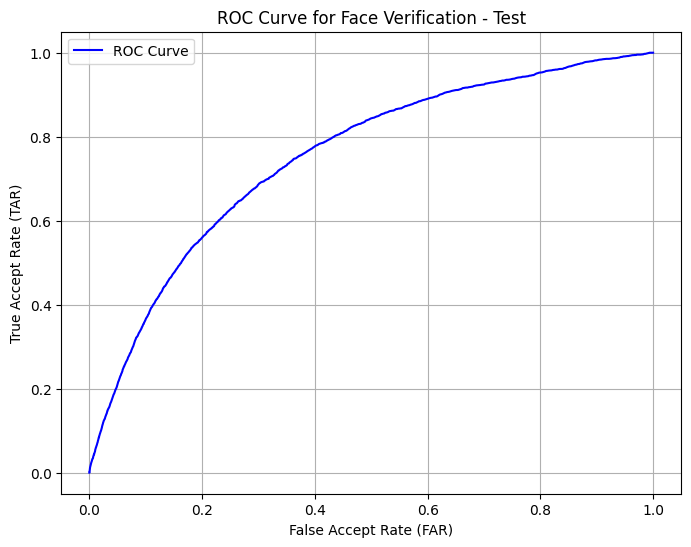

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▄▃▃▂▂▂▁▁
validation_auc,▁▅▄▇▇▇▇███
validation_eer,█▄▄▁▂▁▁▁▁▁
validation_loss,█▄▅▂▂▂▂▂▁▁
validation_tar_at_far_1,▂▄▅▁▄█▂█▁▅
validation_tar_at_far_10,▁▄▃▆▆█▆▇██


wandb: Agent Starting Run: 9f944fx1 with config:
wandb: 	batch_size: 59
wandb: 	embedding_size: 228
wandb: 	lr: 0.0009491043066319216
wandb: 	margin: 0.4065852299501813
wandb: 	weight_decay: 0.9516000002906296


--- Epoch 1 ---


100%|██████████| 15/15 [00:05<00:00,  2.78it/s, mean_loss=0.37350645661354065]


TAR@FAR=10%: 0.13446327684593828
TAR@FAR=5%: 0.07909604520814584
TAR@FAR=1%: 0.021468926564729207
AUC: 0.5716186281065113
EER: 0.4435028248537457
EER Threshold 0.2801973223686218
--- Epoch 2 ---


...

TAR@FAR=10%: 0.27683615820026175
TAR@FAR=5%: 0.18305084746685818
TAR@FAR=1%: 0.057627118654716036
AUC: 0.707722557370249
EER: 0.34745762711471795
EER Threshold 0.5458943843841553
--- Epoch 9 ---


100%|██████████| 15/15 [00:05<00:00,  2.80it/s, mean_loss=0.28534315327803295]


TAR@FAR=10%: 0.2271186440765297
TAR@FAR=5%: 0.12881355933187777
TAR@FAR=1%: 0.02711864407878961
AUC: 0.6986593890599428
EER: 0.3644067796568994
EER Threshold 0.5524518489837646
--- Epoch 10 ---


100%|██████████| 15/15 [00:05<00:00,  2.81it/s, mean_loss=0.26120259960492453]


TAR@FAR=10%: 0.3141242937930607
TAR@FAR=5%: 0.18305084746685818
TAR@FAR=1%: 0.044067796620971045
AUC: 0.7343279389649748
EER: 0.3372881355894092
EER Threshold 0.6051040887832642
--- Test ---
TAR@FAR=10%: 0.27416413374080795
TAR@FAR=5%: 0.15440729483539695
TAR@FAR=1%: 0.049848024318997375
AUC: 0.7026782785681095
EER: 0.3517570925470192
EER Threshold 0.8510919631951982


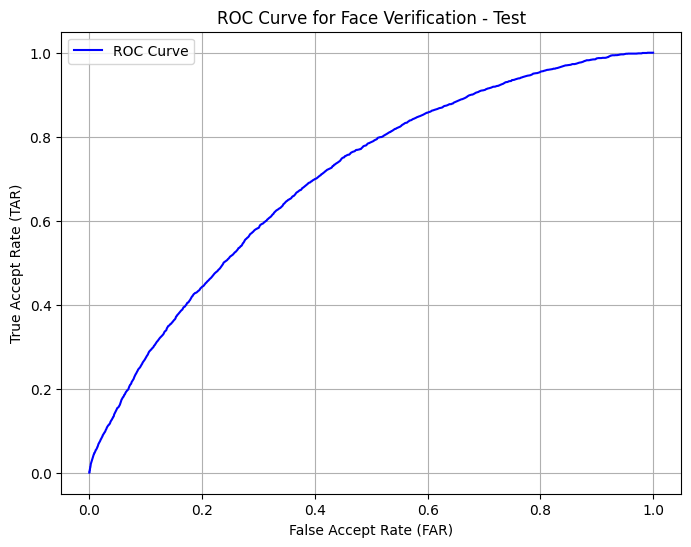

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,███▇▅▄▃▃▁▁
validation_auc,▂▂▁▃▂▆▅▇▇█
validation_eer,▇██▆▇▃▄▂▃▁
validation_loss,▇▇█▆▇▃▄▂▂▁
validation_tar_at_far_1,▂▄▄▂▄▁▃█▃▆
validation_tar_at_far_10,▁▃▁▃▃▅▅▇▅█


In [18]:
sweep_id = wandb.sweep(sweep_config, project="nsiete-project-3")
wandb.agent(sweep_id, function=sweep_simplified, count=5)
wandb.finish()

## 7. Best model

--- Epoch 1 ---


100%|██████████| 13/13 [00:04<00:00,  2.88it/s, mean_loss=0.12915062101987693]


TAR@FAR=10%: 0.4551045510522127
TAR@FAR=5%: 0.27921279213678707
TAR@FAR=1%: 0.0738007380187724
AUC: 0.7976690283434622
EER: 0.27859778597443297
EER Threshold 0.9446958303451538
--- Epoch 2 ---


100%|██████████| 13/13 [00:04<00:00,  2.86it/s, mean_loss=0.10871550841973378]


TAR@FAR=10%: 0.4698646986535072
TAR@FAR=5%: 0.3308733087413177
TAR@FAR=1%: 0.1131611316222243
AUC: 0.8269321254017572
EER: 0.26752767527346216
EER Threshold 0.9874921441078186
--- Epoch 3 ---


...

TAR@FAR=10%: 0.6765067650716297
TAR@FAR=5%: 0.5067650676567433
TAR@FAR=1%: 0.17343173432751002
AUC: 0.8903768557884597
EER: 0.18880688806655832
EER Threshold 1.293056845664978
--- Epoch 14 ---


100%|██████████| 13/13 [00:04<00:00,  2.91it/s, mean_loss=0.06725795266146843]


TAR@FAR=10%: 0.6605166051702274
TAR@FAR=5%: 0.4391143911508104
TAR@FAR=1%: 0.16236162362653928
AUC: 0.8872715664330596
EER: 0.18880688806655832
EER Threshold 1.1048418283462524
--- Epoch 15 ---


100%|██████████| 13/13 [00:04<00:00,  2.82it/s, mean_loss=0.06705970417421597]


TAR@FAR=10%: 0.692496924973032
TAR@FAR=5%: 0.5055350553566356
TAR@FAR=1%: 0.20418204183020683
AUC: 0.8976888477273874
EER: 0.1795817958157493
EER Threshold 1.0221658945083618
--- Test ---
TAR@FAR=10%: 0.7021369385091536
TAR@FAR=5%: 0.5390318360236829
TAR@FAR=1%: 0.2396423898839083
AUC: 0.9031835135218993
EER: 0.17708437348664405
EER Threshold 0.9779676892258622


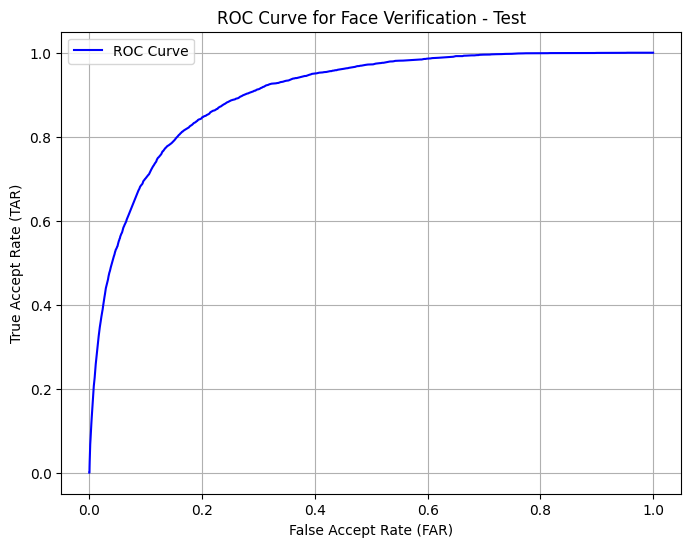

test_auc,▁
test_eer,▁
test_tar_at_far_1,▁
test_tar_at_far_10,▁
test_tar_at_far_5,▁
train_loss,█▅▄▄▃▃▂▂▂▁▁▁▁▁▁
validation_auc,▁▃▅▅▆▇▆▇▇█▇▇▇▇█
validation_eer,█▇▃▄▃▃▄▂▁▁▁▂▂▂▁
validation_loss,█▆▄▄▃▃▄▁▂▁▂▂▂▂▂
validation_tar_at_far_1,▁▃▆▂▇█▄▆▆█▆█▆▅▇
validation_tar_at_far_10,▁▁▄▃▅▇▅▆▇▇▆██▇█


In [23]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

model: nn.Module = NeuralNet(170).to(device)
loss = ShadowLoss(margin=0.25)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0002, weight_decay=0.75)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

wandb.init()
train(model, loss, optimizer, scheduler, 15, train_loader, val_loader)
print("--- Test ---")
test(model, test_subset, test_pairs)
wandb.finish()